<a href="https://colab.research.google.com/github/nlan082/bai_tap_AI/blob/main/2_7_noidien.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 8.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [40]:
foodtype = ctrl.Antecedent(np.arange(0,2.1,0.1), 'foodtype')
weight = ctrl.Antecedent(np.arange(0,2.1,0.1), 'weight')
temperature = ctrl.Antecedent(np.arange(0,61,1), 'temperature')
water = ctrl.Antecedent(np.arange(0,2.1,0.1), 'water')
time = ctrl.Consequent(np.arange(0, 2.1, 0.1), 'time')
heat = ctrl.Consequent(np.arange(0,101,1), 'heat')


In [62]:
foodtype['soft']=fuzz.trimf(foodtype.universe, [0, 0, 1])
foodtype['medium']=fuzz.trimf(foodtype.universe, [0, 1, 2])
foodtype['hard']=fuzz.trimf(foodtype.universe, [1, 2, 2])
weight['light']=fuzz.trimf(weight.universe, [0, 0, 1])
weight['medium']=fuzz.trimf(weight.universe, [0, 1, 2])
weight['heavy']=fuzz.trimf(weight.universe, [1, 2, 2])
temperature['cold']=fuzz.trimf(temperature.universe, [0, 0, 20])
temperature['normal']=fuzz.trimf(temperature.universe, [10, 20, 30])
temperature['hot']=fuzz.trimf(temperature.universe, [20, 40, 60])
water['low']=fuzz.trimf(water.universe, [0, 0, 1])
water['medium']=fuzz.trimf(water.universe, [0, 1, 2])
water['high']=fuzz.trimf(water.universe, [1, 2, 2])
time['short']=fuzz.trimf(time.universe, [0, 0, 1])
time['medium']=fuzz.trimf(time.universe, [0, 1, 2])
time['long']=fuzz.trimf(time.universe, [1, 2, 2])
heat['low']=fuzz.trimf(heat.universe, [0, 0, 60])
heat['medium']=fuzz.trimf(heat.universe, [40, 60, 80])
heat['high']=fuzz.trimf(heat.universe, [60, 100, 100])


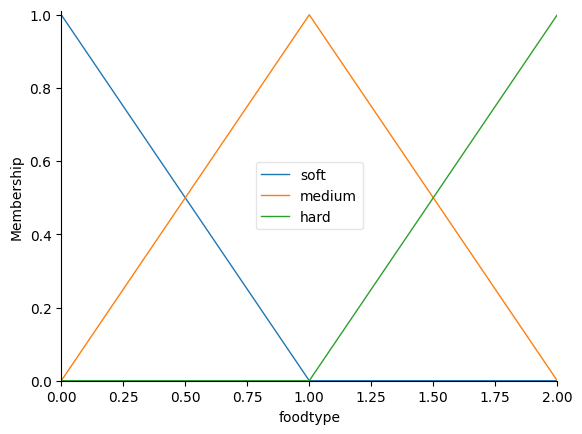

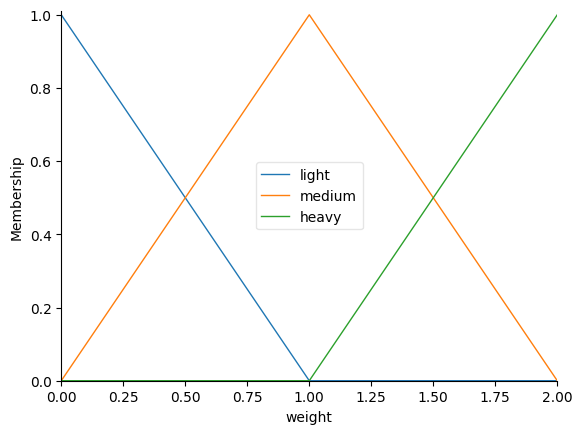

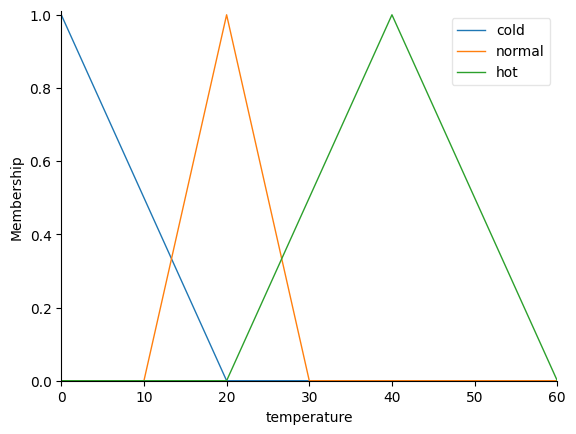

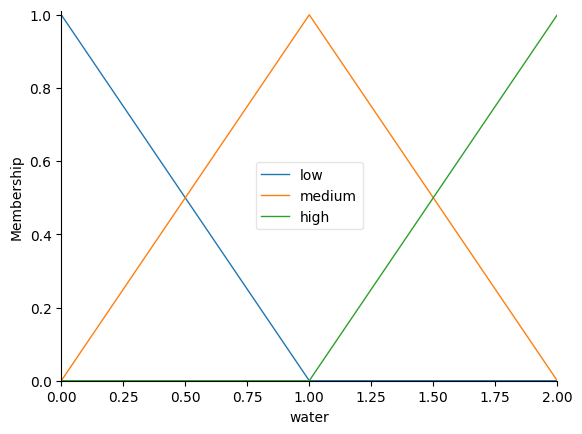

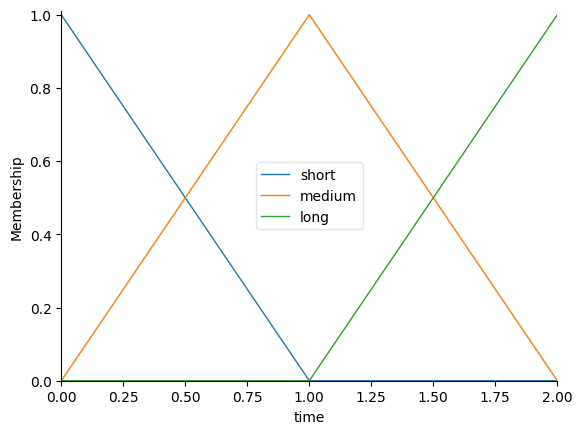

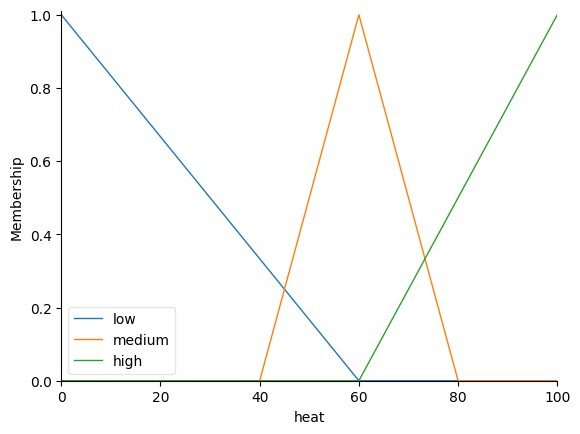

In [63]:
foodtype.view()
weight.view()
temperature.view()
water.view()
time.view()
heat.view()

1.2487858719646803
60.00000000000003


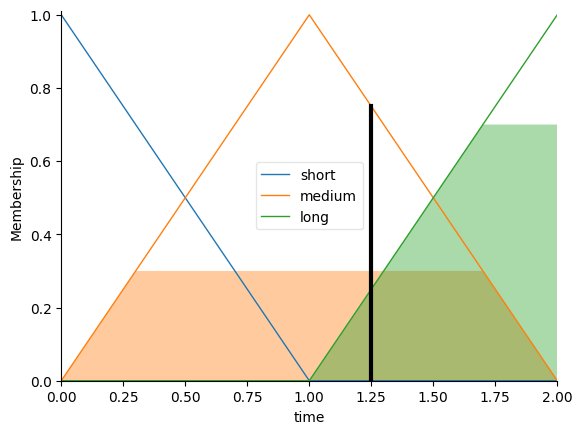

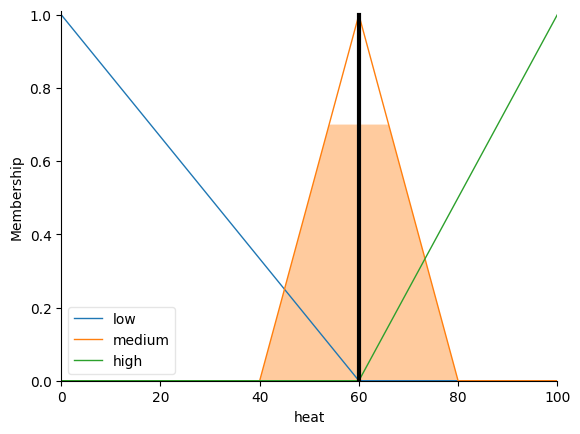

In [65]:
rule1=ctrl.Rule(foodtype['soft']&weight['light'], time['short'])
rule2=ctrl.Rule(foodtype['soft']&weight['heavy'], time['medium'])
rule3=ctrl.Rule(temperature['cold']&water['low'], time['long'])
rule4=ctrl.Rule(temperature['cold']&water['medium'], time['medium'])
rule5=ctrl.Rule(temperature['normal']&water['low'], (time['medium'], heat['low']))
rule6=ctrl.Rule(temperature['normal']&water['medium'], (time['medium'], heat['medium']))
rule7=ctrl.Rule(temperature['normal']&water['high'], (time['long'], heat['medium']))
rule8=ctrl.Rule(temperature['hot']&water['low'], (time['long'], heat['high']))

mon_ctrl=ctrl.ControlSystem([rule1,rule2,rule3,rule4,rule5,rule6,rule7,rule8])
mon_sim=ctrl.ControlSystemSimulation(mon_ctrl)
mon_sim.input['foodtype']=1.5
mon_sim.input['weight']=1.2
mon_sim.input['temperature']=20
mon_sim.input['water']=1.7
mon_sim.compute()
print(mon_sim.output['time'])
print(mon_sim.output['heat'])
time.view(sim=mon_sim)
heat.view(sim=mon_sim)